# Calgary development permits: Complete study-period exploration

Download and explore all configured study periods: **Before**, **During**, and **Early Post-Repeal**, from August 6, 2022 through the snapshot retrieval horizon. Run from top to bottom. The pinned snapshot is reused offline by default; set `REFRESH_DOWNLOAD=True` deliberately to obtain a new immutable snapshot.

The notebook reuses the project's Adapter/Repository download workflow, cleaning and classification components, feature functions, validation strategies, and analysis/chart APIs. It does not define a separate analysis implementation.

Counts measure applications, not dwelling units or completed homes. Before/During comparisons are observational; the short post-repeal window is context only. Retrieval dates define exposure by convention and do not prove source completeness. Partial months and seasons require care; classification warnings remain visible.

In [3]:
from pathlib import Path
from datetime import timedelta
from dataclasses import asdict
from io import BytesIO
import hashlib
import json
import sys

import pandas as pd
import matplotlib
from IPython.display import display, Image
from pandas.testing import assert_frame_equal

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "pyproject.toml").is_file() and (path / "src/dp_activity").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from within the project repository.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from dp_activity import StudyPeriod
from dp_activity.config import load_config
from dp_activity.cli import (
    build_download_command, _default_column_map,
    _default_classification_field_map, _snapshot_observation_end,
)
from dp_activity.repositories.raw_data_repository import RawDataRepository
from dp_activity.profiling.data_profiler import DataProfiler
from dp_activity.cleaning.permit_cleaner import PermitCleaner
from dp_activity.classification.rule_loader import RuleLoader
from dp_activity.classification.classifier import PermitClassifier
from dp_activity.validation.schema_validator import SchemaValidator
from dp_activity.validation.data_quality_validator import DataQualityValidator
from dp_activity.validation.classification_validator import ClassificationValidator
from dp_activity.features.period_features import add_period_features
from dp_activity.features.season_features import add_season_features
from dp_activity.features.processing_features import add_processing_features
from dp_activity.analysis.volume_analysis import VolumeAnalysis
from dp_activity.analysis.type_analysis import TypeAnalysis
from dp_activity.analysis.geography_analysis import GeographyAnalysis
from dp_activity.analysis.processing_analysis import ProcessingAnalysis
from dp_activity.analysis.rezoning_analysis import RezoningAnalysis
from dp_activity.analysis.seasonal_analysis import SeasonalAnalysis
from dp_activity.visualization.chart_factory import ChartFactory

pd.set_option("display.max_rows", 15)
pd.set_option("display.max_colwidth", 100)
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | Matplotlib {matplotlib.__version__}")

Python 3.13.14 | pandas 2.2.3 | Matplotlib 3.10.8


In [4]:
SETTINGS_PATH = ROOT / "config/settings.yaml"
SNAPSHOT_FILENAME = "development_permits_20260925_045241.parquet"
REFRESH_DOWNLOAD = False
REVIEW_LIMIT = 10

config = load_config(SETTINGS_PATH)
primary_date_field = config.raw["analysis"]["primary_date_field"]
source_date_field = next(
    source for source, target in _default_column_map().items()
    if target == primary_date_field
)
download_command = build_download_command(config)
expected_where = download_command.where
if REFRESH_DOWNLOAD or SNAPSHOT_FILENAME is None:
    print("Downloading all matching records with pagination; no sample limit.", flush=True)
    downloaded_rows, downloaded_paths = download_command.execute()
    snapshot_path = next(path for path in downloaded_paths if path.suffix == ".parquet")
    SNAPSHOT_FILENAME = snapshot_path.name
    print(f"Downloaded {downloaded_rows:,} records.")
    for path in downloaded_paths:
        print(path.relative_to(ROOT))
else:
    snapshot_path = config.raw_data_dir / SNAPSHOT_FILENAME
    print("Reusing the pinned snapshot offline.")
if not snapshot_path.is_file():
    raise FileNotFoundError(f"Missing pinned snapshot: {snapshot_path}")
print("Snapshot:", SNAPSHOT_FILENAME)
print("Source filter:", expected_where)

Reusing the pinned snapshot offline.
Snapshot: development_permits_20260925_045241.parquet
Source filter: (applieddate >= '2022-08-06T00:00:00' AND applieddate < '2024-08-06T00:00:00') OR (applieddate >= '2024-08-06T00:00:00' AND applieddate < '2026-08-04T00:00:00') OR (applieddate >= '2026-08-04T00:00:00')


## Verify the frozen snapshot and coverage

Check checksum, row count, source identity, query, application dates, and period totals before analysis. The open-ended post-repeal period stops at the UTC retrieval date. Display the latest observed application separately so source lag is visible.

In [5]:
repository = RawDataRepository(config.raw_data_dir)
raw = repository.load_snapshot(snapshot_path)
raw_before = raw.copy(deep=True)
sidecar_path = snapshot_path.with_suffix(snapshot_path.suffix + ".metadata.json")
metadata = json.loads(sidecar_path.read_text(encoding="utf-8"))
snapshot_sha256 = hashlib.sha256(snapshot_path.read_bytes()).hexdigest()
assert metadata["sha256"] == snapshot_sha256, "Snapshot checksum mismatch."
assert metadata["row_count"] == len(raw), "Snapshot row-count mismatch."
assert metadata["dataset_id"] == config.raw["data_source"]["dataset_id"]
query = metadata["query"]
if isinstance(query, str):
    query = json.loads(query)
assert query["where"] == expected_where, "Snapshot does not cover the configured query."
observation_end = _snapshot_observation_end(snapshot_path, None)
covered_periods = list(config.periods)
covered_labels = [period.name for period in covered_periods]
application_dates = pd.to_datetime(raw[source_date_field], errors="raise")
assert not raw.empty and application_dates.notna().all()
assert application_dates.dt.date.between(covered_periods[0].start, observation_end).all()
coverage_rows = []
for period in covered_periods:
    end = min(period.end, observation_end) if period.end else observation_end
    dates = application_dates.loc[application_dates.dt.date.between(period.start, end)]
    coverage_rows.append({
        "Period": period.name, "WindowStart": period.start, "WindowEnd": end,
        "ExposureDays": (end - period.start).days + 1, "AllPermitCount": len(dates),
        "FirstObservedApplication": dates.min(), "LastObservedApplication": dates.max(),
        "ContextOnly": period.end is None,
    })
coverage_table = pd.DataFrame(coverage_rows)
assert int(coverage_table["AllPermitCount"].sum()) == len(raw)
display(coverage_table)
display(pd.DataFrame([{
    "snapshot": snapshot_path.name, "records": len(raw),
    "retrieved_at_utc": metadata["retrieved_at_utc"],
    "snapshot_sha256": snapshot_sha256,
    "settings_sha256": hashlib.sha256(SETTINGS_PATH.read_bytes()).hexdigest(),
    "rules_sha256": hashlib.sha256(config.classification_rules_path.read_bytes()).hexdigest(),
}]))
print("Source-lag check: latest application date is", application_dates.max())
print("Retrieval horizon is a coverage convention, not proof of complete reporting.")

,Period,WindowStart,WindowEnd,ExposureDays,AllPermitCount,FirstObservedApplication,LastObservedApplication,ContextOnly
0,Before,2022-08-06,2024-08-05,731,16637,2022-08-06,2024-08-05,False
1,During,2024-08-06,2026-08-03,728,13866,2024-08-06,2026-08-03,False
2,Early Post-Repeal,2026-08-04,2026-09-25,53,836,2026-08-04,2026-09-23,True


,snapshot,records,retrieved_at_utc,snapshot_sha256,settings_sha256,rules_sha256
0,development_permits_20260925_045241.parquet,31339,2026-09-25 04:52:41.094573+00:00,e793e45c2ae197257a6c814108aafa699fbdf9ebcee00b1bc6f638f192b3f348,7da0cab3bd1dde0b7346aa75a384490107a49039db6138bb32bfb0918db61eb9,2dc55f173351e9caac7e41d0083b464436234b31a1b55b9c5418524ddeb1636c


Source-lag check: latest application date is 2026-09-23 00:00:00
Retrieval horizon is a coverage convention, not proof of complete reporting.


## Source quality, cleaning, and classification

Profile missingness and duplicate identifiers. Cleaning preserves all source records. Ordered classification rules determine residential inclusion; matching a rule does not establish accuracy. Review unmatched and overlapping evidence below.

In [6]:
profiler = DataProfiler()
source_categories = [
    name for name in ("category", "proposedusedescription", "landusedistrict", "statuscurrent")
    if name in raw
]
raw_profile = profiler.profile(raw, source_categories)
display(raw_profile["summary"])
display(raw_profile["dtypes"])
display(raw_profile["missingness"].sort_values("missing_percentage", ascending=False).head(15))
display(raw_profile["permit_uniqueness"])
display(raw_profile["duplicate_examples"].head(REVIEW_LIMIT))
display(raw_profile["date_ranges"])
for name in source_categories:
    print(f"Source distribution: {name}")
    display(raw_profile[name].head(REVIEW_LIMIT))

,row_count,column_count
0,31339,34


,column,dtype
0,point,object
1,permitnum,object
2,address,object
3,applicant,object
4,category,object
...,...,...
29,canceledrefuseddate,object
30,sdabnumber,object
31,sdabhearingdate,object
32,sdabdecision,object


,column,missing_count,missing_percentage
32,sdabdecision,30949,98.755544
30,sdabnumber,30946,98.745971
33,sdabdecisiondate,30942,98.733208
31,sdabhearingdate,30935,98.710871
29,canceledrefuseddate,25376,80.972590
3,applicant,13636,43.511280
14,releasedate,9167,29.251093
15,mustcommencedate,7235,23.086250
13,decisiondate,7037,22.454450
17,decisionby,6824,21.774785


,column,non_missing_count,unique_count,duplicate_row_count,duplicate_excess_count
0,permitnum,31339,31339,0,0


,column,row_position,permit_number


...

,value,count,percentage
0,SECONDARY SUITE,5038,16.075816
1,SINGLE DETACHED DWELLING,2950,9.413191
2,HOME OCCUPATION - CLASS 2,2645,8.439963
3,SIGN - CLASS B,2318,7.396535
4,ACCESSORY RESIDENTIAL BUILDING,1652,5.271387
5,DECK,1487,4.744887
6,BACKYARD SUITE,803,2.562303
7,ACCESSORY RESIDENTIAL BUILDING; SINGLE DETACHED DWELLING,619,1.975175
8,CHILD CARE SERVICE,601,1.917738
9,GENERAL INDUSTRIAL - LIGHT,574,1.831584


Source distribution: landusedistrict


,value,count,percentage
0,R-CG,6150,19.624111
1,R-C1,3861,12.320112
2,DC,3335,10.641692
3,R-G,2614,8.341045
4,R-C2,2127,6.787070
5,R-1N,1862,5.941479
6,I-G,1813,5.785124
7,R-1,685,2.185775
8,I-C,579,1.847538
9,C-COR3 f1.0h12,350,1.116819


Source distribution: statuscurrent


,value,count,percentage
0,Released,22227,70.924407
1,Cancelled,5563,17.751045
2,Pending Release,959,3.060085
3,Hold,694,2.214493
4,In Advertising,544,1.735856
5,In Circulation,358,1.142347
6,Under Review,256,0.816874
7,Refused,197,0.628610
8,Lapsed,113,0.360573
9,Pending Decision,83,0.264846


In [7]:
column_map = _default_column_map()
analysis_settings = config.raw["analysis"]
date_columns = list(dict.fromkeys([
    analysis_settings["primary_date_field"],
    analysis_settings["processing_time"]["end_field"],
]))
cleaner = PermitCleaner(column_map, date_columns)
cleaned = cleaner.clean(raw)
assert_frame_equal(raw, raw_before)
assert len(cleaned) == len(raw)
assert cleaned.index.equals(raw.index)

clean_categories = [column_map.get(name, name) for name in source_categories]
clean_profile = profiler.profile(cleaned, clean_categories)
before_missing = raw_profile["missingness"].copy()
before_missing["column"] = before_missing["column"].replace(column_map)
comparison = before_missing[["column", "missing_count"]].merge(
    clean_profile["missingness"][["column", "missing_count"]],
    on="column", how="left", suffixes=("_before", "_after"),
)
comparison["change"] = comparison["missing_count_after"] - comparison["missing_count_before"]
display(comparison.sort_values("change", ascending=False).head(15))
invalid_columns = [name for name in cleaned.columns if name.endswith("_invalid")]
display(cleaned[invalid_columns].sum().rename("flagged_rows").to_frame())
print(f"Preserved {len(cleaned)} records and the original row index.")

,column,missing_count_before,missing_count_after,change
0,point,54,54,0
1,permit_number,0,0,0
2,address,4,4,0
3,applicant,13636,13636,0
4,category,15,15,0
5,description,0,0,0
6,proposed_use_code,0,0,0
7,proposed_use_description,0,0,0
8,permitteddiscretionary,0,0,0
9,land_use_district,0,0,0


,flagged_rows
applied_date_invalid,0
decision_date_invalid,0
latitude_invalid,0
longitude_invalid,0


Preserved 31339 records and the original row index.


In [8]:
rules = RuleLoader().load(config.classification_rules_path)
classification_settings = analysis_settings["classification"]
classifier = PermitClassifier(
    rules,
    _default_classification_field_map(),
    unmatched_action=classification_settings["unmatched_action"],
    case_sensitive=classification_settings["case_sensitive"],
)
cleaned_before = cleaned.copy(deep=True)
classified = classifier.classify(cleaned)
coverage = classifier.coverage_report(classified)
assert_frame_equal(cleaned, cleaned_before)
assert len(classified) == len(raw)
assert int(coverage["record_count"].sum()) == len(raw)

display(pd.DataFrame([{
    "enabled_rules": len(rules),
    "records": len(classified),
    "matched": int(classified["ClassificationRule"].notna().sum()),
    "unmatched": int(classified["ClassificationRule"].isna().sum()),
    "needs_review": int(classified["ClassificationNeedsReview"].sum()),
    "overlapping_matches": int(classified["ClassificationConflictCount"].gt(0).sum()),
    "included_residential": int(classified["IncludeResidential"].sum()),
}]))
display(coverage.sort_values("record_count", ascending=False).head(15))
display(classified.groupby(
    ["ResidentialType", "IncludeResidential", "ValidationStatus"], dropna=False
).size().rename("records").reset_index().sort_values("records", ascending=False).head(15))

,enabled_rules,records,matched,unmatched,needs_review,overlapping_matches,included_residential
0,34,31339,31329,10,2635,29798,14277


,ClassificationRule,ValidationStatus,ClassificationNeedsReview,record_count,matched_count,unmatched_count,conflict_count,additional_match_count,record_percentage
0,HF-016,validated_2026_sample,False,5066,5066,0,5066,20363,16.165162
4,HF-905,validated_2026_sample,False,4440,4440,0,4440,4440,14.167651
12,HF-010,validated_2026_sample,False,4165,4165,0,4165,16066,13.290150
3,HF-900,validated_2026_sample,False,3868,3868,0,3868,3868,12.342449
2,HF-901,validated_2026_sample,False,2645,2645,0,2645,2645,8.439963
5,HF-906,validated_2026_sample,False,1855,1855,0,1855,1855,5.919142
10,HF-018,validated_2026_sample,False,1738,1738,0,1738,3527,5.545806
8,HF-999,review,True,1531,1531,0,0,0,4.885287
16,HF-005,validated_2026_sample,False,1020,1020,0,1020,5774,3.254731
1,HF-014,validated_2026_sample,False,1004,1004,0,1004,4192,3.203676


,ResidentialType,IncludeResidential,ValidationStatus,records
6,Non-Residential,False,validated_2026_sample,11340
14,Secondary Suite,True,validated_2026_sample,5089
16,Single Detached,True,validated_2026_sample,4899
11,Residential Non-Housing,False,validated_2026_sample,1855
1,Accessory Residential Building,False,validated_2026_sample,1738
19,Unclassified,False,review,1531
15,Semi-Detached,True,validated_2026_sample,1088
2,Backyard Suite,True,validated_2026_sample,1015
4,Multi-Residential,True,validated_2026_sample,850
13,Rowhouse,True,validated_2026_sample,789


In [9]:
review_columns = [name for name in (
    "permit_number", "category", "proposed_use_description", "description",
    "raw_category", "raw_proposed_use_description", "ClassificationRule",
    "ValidationStatus", "ResidentialType", "ClassificationNeedsReview",
    "ClassificationMatchedRules",
) if name in classified]
for label, mask in {
    "Unmatched": classified["ClassificationRule"].isna(),
    "Needs review": classified["ClassificationNeedsReview"],
    "Potential overlaps": classified["ClassificationConflictCount"].gt(0),
}.items():
    print(f"{label}: {int(mask.sum())} records; showing at most {REVIEW_LIMIT}.")
    display(classified.loc[mask, review_columns].head(REVIEW_LIMIT))

winning_counts = classified["ClassificationRule"].value_counts()
all_match_counts = classified["ClassificationMatchedRules"].explode().dropna().value_counts()
rule_coverage = pd.DataFrame([{
    "rule_id": rule.rule_id, "priority": rule.priority, "field": rule.field,
    "match_value": rule.match_value, "validation_status": rule.validation_status,
    "winning_records": int(winning_counts.get(rule.rule_id, 0)),
    "all_matching_records": int(all_match_counts.get(rule.rule_id, 0)),
} for rule in rules])
display(rule_coverage)
display(raw_profile["description_examples"].head(REVIEW_LIMIT))

Unmatched: 10 records; showing at most 10.


,permit_number,category,proposed_use_description,description,raw_category,raw_proposed_use_description,ClassificationRule,ValidationStatus,ResidentialType,ClassificationNeedsReview,ClassificationMatchedRules
433,DP2022-05985,None,VEHICLE SALES - MAJOR,CHANGE OF USE: VEHICLE SALES - MAJOR,None,VEHICLE SALES - MAJOR,<NA>,unmatched,Review,True,()
2534,DP2022-08287,None,RETAIL AND CONSUMER SERVICE,CHANGE OF USE: RETAIL AND CONSUMER SERVICE,None,RETAIL AND CONSUMER SERVICE,<NA>,unmatched,Review,True,()
9474,DP2023-07200,None,BUILDING SUPPLY CENTRE,CHANGE OF USE: BUILDING SUPPLY CENTRE,None,BUILDING SUPPLY CENTRE,<NA>,unmatched,Review,True,()
9981,DP2023-07748,None,HEALTH CARE SERVICE,REVISION: HEALTH CARE SERVICE (CHANGE OF USE TO DP2020-3951),None,HEALTH CARE SERVICE,<NA>,unmatched,Review,True,()
14595,DP2024-03548,None,BED AND BREAKFAST,: BED AND BREAKFAST,None,BED AND BREAKFAST,<NA>,unmatched,Review,True,()
17257,DP2024-06426,None,SPECIAL FUNCTION - CLASS 1,"TEMPORARY USE: SPECIAL FUNCTION - CLASS 1 (BEAKERHEAD, SEPT 19-22 2024)",None,SPECIAL FUNCTION - CLASS 1,<NA>,unmatched,Review,True,()
20159,DP2025-00506,None,RESTAURANT: FOOD SERVICE ONLY,CHANGE OF USE: RESTAURANT: FOOD SERVICE ONLY,None,RESTAURANT: FOOD SERVICE ONLY,<NA>,unmatched,Review,True,()
23578,DP2025-04311,None,HEALTH CARE SERVICE,: HEALTH CARE SERVICE,None,HEALTH CARE SERVICE,<NA>,unmatched,Review,True,()
24171,DP2025-04967,None,SPECIALTY FOOD STORE,CHANGE OF USE: SPECIALTY FOOD STORE,None,SPECIALTY FOOD STORE,<NA>,unmatched,Review,True,()
30002,DP2026-03354,None,VEHICLE STORAGE,: VEHICLE STORAGE,None,VEHICLE STORAGE,<NA>,unmatched,Review,True,()


Needs review: 2635 records; showing at most 10.


,permit_number,category,proposed_use_description,description,raw_category,raw_proposed_use_description,ClassificationRule,ValidationStatus,ResidentialType,ClassificationNeedsReview,ClassificationMatchedRules
12,DP2022-05555,Commercial - Other Areas,CAR WASH - MULTI-VEHICLE,NEW: CAR WASH - MULTI-VEHICLE,Commercial - Other Areas,CAR WASH - MULTI-VEHICLE,HF-902,fallback,Non-Residential,True,"(HF-902, HF-999)"
14,DP2022-05519,Temporary Structure,POST-SECONDARY LEARNING INSTITUTION,TEMPORARY USE: POST-SECONDARY LEARNING INSTITUTION (RECREATIONAL FACILITY BUILDING - TEN YEARS),Temporary Structure,POST-SECONDARY LEARNING INSTITUTION,HF-999,review,Unclassified,True,"(HF-999,)"
40,DP2022-05557,Commercial - Other Areas,CHILD CARE SERVICE; LIQUOR STORE; RETAIL AND CONSUMER SERVICE,"NEW: LIQUOR STORE, CHILD CARE SERVICE, RETAIL AND CONSUMER SERVICE (6 PHASES, 5 BUILDINGS)",Commercial - Other Areas,CHILD CARE SERVICE; LIQUOR STORE; RETAIL AND CONSUMER SERVICE,HF-902,fallback,Non-Residential,True,"(HF-902, HF-999)"
48,DP2022-05564,Renovations - Non-Residential,DECK,REVISION: MULTI-RESIDENTIAL (DECK),Renovations - Non-Residential,DECK,HF-999,review,Unclassified,True,"(HF-999,)"
82,DP2022-05602,Renovations - Non-Residential,GENERAL INDUSTRIAL - LIGHT,EXTERIOR RENOVATIONS: GENERAL INDUSTRIAL - LIGHT (REFURBISH BUILDING FAÇADE),Renovations - Non-Residential,GENERAL INDUSTRIAL - LIGHT,HF-999,review,Unclassified,True,"(HF-999,)"
89,DP2022-05613,Commercial - Other Areas,RETAIL AND CONSUMER SERVICE; VETERINARY CLINIC,"NEW: VETERINARY CLINIC, RETAIL AND CONSUMER SERVICE (1 BUILDING)",Commercial - Other Areas,RETAIL AND CONSUMER SERVICE; VETERINARY CLINIC,HF-902,fallback,Non-Residential,True,"(HF-902, HF-999)"
91,DP2022-05614,Temporary Structure,GENERAL INDUSTRIAL - LIGHT,TEMPORARY USE: GENERAL INDUSTRIAL - LIGHT (STORAGE TENT) - 5 YEARS,Temporary Structure,GENERAL INDUSTRIAL - LIGHT,HF-999,review,Unclassified,True,"(HF-999,)"
121,DP2022-05630,Development Design Guidelines,TEMPORARY RESIDENTIAL SALES CENTRE,TEMPORARY USE: TEMPORARY RESIDENTIAL SALES CENTRE (3 UNITS) - 2 YEARS,Development Design Guidelines,TEMPORARY RESIDENTIAL SALES CENTRE,HF-999,review,Unclassified,True,"(HF-999,)"
133,DP2022-05659,Temporary Structure,TEMPORARY RESIDENTIAL SALES CENTRE,TEMPORARY USE: TEMPORARY RESIDENTIAL SALES CENTRE (4 YEARS),Temporary Structure,TEMPORARY RESIDENTIAL SALES CENTRE,HF-999,review,Unclassified,True,"(HF-999,)"
154,DP2022-05680,Renovations - Non-Residential,"BREWERY, WINERY AND DISTILLERY; OUTDOOR CAFE; RESTAURANT: LICENSED","EXTERIOR RENOVATIONS: BREWERY, WINERY AND DISTILLERY, RESTAURANT: LICENSED (NEW GARAGE DOOR); RE...",Renovations - Non-Residential,"BREWERY, WINERY AND DISTILLERY; OUTDOOR CAFE; RESTAURANT: LICENSED",HF-999,review,Unclassified,True,"(HF-999,)"


Potential overlaps: 29798 records; showing at most 10.


,permit_number,category,proposed_use_description,description,raw_category,raw_proposed_use_description,ClassificationRule,ValidationStatus,ResidentialType,ClassificationNeedsReview,ClassificationMatchedRules
0,DP2022-05518,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT) - PARKING STALL SIZE,Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
1,DP2022-05515,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT),Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
2,DP2022-05516,Residential - Secondary Suite,BACKYARD SUITE,NEW: BACKYARD SUITE (CONVERTING EXISTING GARAGE),Residential - Secondary Suite,BACKYARD SUITE,HF-014,validated_2026_sample,Backyard Suite,False,"(HF-014, HF-015, HF-102, HF-106, HF-999)"
3,DP2022-05517,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT),Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
4,DP2022-05513,Home Occupation Class 2,HOME OCCUPATION - CLASS 2,TEMPORARY USE: HOME OCCUPATION - CLASS 2 (MOTOR VEHICLE DEALER - 18 MONTHS),Home Occupation Class 2,HOME OCCUPATION - CLASS 2,HF-901,validated_2026_sample,Non-Residential,False,"(HF-901, HF-999)"
5,DP2022-05512,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT),Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
6,DP2022-05514,Signs - Permitted Use,SIGN - CLASS B,NEW: SIGN - CLASS B (FASCIA SIGN),Signs - Permitted Use,SIGN - CLASS B,HF-900,validated_2026_sample,Non-Residential,False,"(HF-900, HF-999)"
7,DP2022-05549,Home Occupation Class 2,HOME OCCUPATION - CLASS 2,TEMPORARY USE: HOME OCCUPATION - CLASS 2 (AESTHETICS - 18 MONTHS),Home Occupation Class 2,HOME OCCUPATION - CLASS 2,HF-901,validated_2026_sample,Non-Residential,False,"(HF-901, HF-999)"
8,DP2022-05550,Change of Use - Permitted Use,RETAIL AND CONSUMER SERVICE,REVISION: RETAIL AND CONSUMER SERVICE (CHANGE OF USE TO DP2016-4510),Change of Use - Permitted Use,RETAIL AND CONSUMER SERVICE,HF-905,validated_2026_sample,Non-Residential,False,"(HF-905, HF-999)"
9,DP2022-05551,Relaxation - Existing - Compliance Follow-Up,DECK,RELAXATION: PRIVACY WALL (EXISTING) - HEIGHT,Relaxation - Existing - Compliance Follow-Up,DECK,HF-906,validated_2026_sample,Residential Non-Housing,False,"(HF-906, HF-999)"


,rule_id,priority,field,match_value,validation_status,winning_records,all_matching_records
0,HF-001,10,proposedusedescription,ROWHOUSE BUILDING,validated_2026_sample,717,717
1,HF-002,11,description,ROWHOUSE,validated_2026_sample,72,769
2,HF-003,20,proposedusedescription,TOWNHOUSE,provisional,367,411
3,HF-004,21,description,TOWNHOUSE,validated_2026_sample,11,411
4,HF-005,30,proposedusedescription,SEMI-DETACHED DWELLING,validated_2026_sample,1020,1065
...,...,...,...,...,...,...,...
29,HF-903,903,category,Industrial,validated_2026_sample,266,266
30,HF-904,904,category,Mixed Use,validated_2026_sample,121,167
31,HF-905,905,category,Change of Use,validated_2026_sample,4440,4559
32,HF-906,906,category,Relaxation,validated_2026_sample,1855,5487


,column,row_position,description,character_count
0,description,28947,CHANGE OF USE: NEW: SIGN - CLASS D (4 CANOPY SIGNS); NEW: SIGN - CLASS B (1 FASCIA SIGN); CHANGE...,463
1,description,2913,REVISION: ASSISTED LIVING (PARKING & MECHANICAL EQUIPMENT) - 60(1)(C) ALL ELECTRICAL AND MECHANI...,416
2,description,4157,"REVISION: RETAIL AND CONSUMER SERVICE, CHILD CARE SERVICE (168 CHILDREN, OUTDOOR PLAY AREA) HEAL...",410
3,description,14707,RELAXATION: SINGLE DETACHED DWELLING (EXISTING) - BUILDING SETBACK FROM SIDE & REAR PROPERTY LIN...,390
4,description,9815,CHANGE OF USE: RESTAURANT (2) (WITHIN EXISTING AUTOMOTIVE SERVICE); EXTERIOR RENOVATIONS: AUTOMO...,369
5,description,30772,"REVISION: CHANGES TO DP2024-04538 (PARKING, LANDSCAPING, WASTE & RECYCLING, EXTERIOR FINISHING M...",348
6,description,21489,"TEMPORARY USE: MANUFACTURING, FABRICATION, PROCESSING, ASSEMBLY, DISASSEMBLY, PRODUCTION OR PACK...",334
7,description,22702,"CHANGES TO SITE PLAN: AUTOMOTIVE SALES, AUTOMOTIVE SERVICE (INCREASED GROSS FLOOR AREA, REDUCTIO...",331
8,description,534,"CHANGE OF USE: BREWERY, WINERY AND DISTILLERY; EXTERIOR RENOVATIONS: BREWERY, WINERY AND DISTILL...",329
9,description,18249,"TEMPORARY USE: MANUFACTURING, FABRICATION, PROCESSING, ASSEMBLY, DISASSEMBLY, PRODUCTION OR PACK...",325


## Period, season, and processing eligibility

Use application dates to assign periods. Seasons crossing study boundaries are flagged partial. Processing summaries exclude invalid durations and account for the retrieval horizon; recent applications have less follow-up.

In [10]:
classified_before_features = classified.copy(deep=True)
observation_end = _snapshot_observation_end(snapshot_path, None)
processing_settings = analysis_settings["processing_time"]
feature_periods = list(config.periods)

period_permits = add_period_features(
    classified,
    date_column=analysis_settings["primary_date_field"],
    periods=feature_periods,
    decision_date_column=processing_settings["end_field"],
)
season_permits = add_season_features(
    period_permits,
    date_column=analysis_settings["primary_date_field"],
    season_months={
        value.get("label", key): value["months"]
        for key, value in config.raw["seasons"].items()
    },
    analysis_windows=feature_periods,
    observation_end=observation_end,
)
featured = add_processing_features(
    season_permits,
    applied_date_column=processing_settings["start_field"],
    decision_date_column=processing_settings["end_field"],
    minimum_days=processing_settings.get("minimum_days", 0),
    observation_end=observation_end,
)
assert_frame_equal(classified, classified_before_features)
assert_frame_equal(featured[classified.columns], classified)
assert_frame_equal(season_permits[period_permits.columns], period_permits)
assert_frame_equal(featured[season_permits.columns], season_permits)
assert len(featured) == len(raw) and featured.index.equals(raw.index)
assert featured["Period"].isin(covered_labels).all()

print(f"Observation horizon (snapshot retrieval date, UTC): {observation_end}")
print("Period counts: all loaded permit records.")
display(featured.groupby("Period", observed=True, dropna=False).size().rename("records").to_frame())
print("Decision-period boundary crossings; missing means not assessable.")
display(featured["CrossesPeriodBoundary"].value_counts(dropna=False).rename("records").to_frame())
season_summary = featured.groupby(
    ["Period", "SeasonSortKey", "SeasonLabel", "SeasonStartDate", "SeasonEndDate",
     "IsCompleteSeason", "IsPartialSeason"], observed=True, dropna=False,
).size().rename("records").reset_index().sort_values("SeasonSortKey")
assert int(season_summary["records"].sum()) == len(featured)
display(season_summary)

processing_flags = [
    "HasValidProcessingDays", "HasNegativeProcessingDays", "IsPending",
    "IsRightCensored", "ProcessingDateMissing", "ProcessingDateInvalid", "IsAfterObservationEnd",
]
print("Processing flags: overlapping counts, not mutually exclusive groups.")
display(featured[processing_flags].sum().rename("records").to_frame())
valid_durations = featured.loc[featured["HasValidProcessingDays"], "ProcessingDays"]
print("Calendar-day duration summary: valid records only, all permit types.")
display(valid_durations.describe(percentiles=[0.25, 0.5, 0.75]).to_frame("days"))
display(pd.DataFrame([{
    "total_records": len(featured),
    "valid_duration_records": len(valid_durations),
    "excluded_duration_records": len(featured) - len(valid_durations),
    "known_follow_up_records": int(featured["FollowUpDays"].notna().sum()),
    "observation_end": observation_end,
}]))
display(featured[[
    "permit_number", "Period", "DecisionPeriod", "CrossesPeriodBoundary",
    "SeasonLabel", "IsCompleteSeason", "ProcessingDays", "HasValidProcessingDays",
    "IsPending", "IsRightCensored", "FollowUpDays",
]].head(REVIEW_LIMIT))

Observation horizon (snapshot retrieval date, UTC): 2026-09-25
Period counts: all loaded permit records.


,records
Period,
Before,16637
During,13866
Early Post-Repeal,836


Decision-period boundary crossings; missing means not assessable.


,records
CrossesPeriodBoundary,
False,22623
<NA>,7037
True,1679


,Period,SeasonSortKey,SeasonLabel,SeasonStartDate,SeasonEndDate,IsCompleteSeason,IsPartialSeason,records
0,Before,202206,Summer 2022,2022-06-01,2022-08-31,False,True,607
1,Before,202209,Fall 2022,2022-09-01,2022-11-30,True,False,1844
2,Before,202212,Winter 2022–23,2022-12-01,2023-02-28,True,False,1653
3,Before,202303,Spring 2023,2023-03-01,2023-05-31,True,False,2098
4,Before,202306,Summer 2023,2023-06-01,2023-08-31,True,False,2327
...,...,...,...,...,...,...,...,...
15,During,202512,Winter 2025–26,2025-12-01,2026-02-28,True,False,1601
16,During,202603,Spring 2026,2026-03-01,2026-05-31,True,False,1906
17,During,202606,Summer 2026,2026-06-01,2026-08-31,False,True,1205
18,Early Post-Repeal,202606,Summer 2026,2026-06-01,2026-08-31,False,True,471


...

,records
HasValidProcessingDays,24298
HasNegativeProcessingDays,0
IsPending,7037
IsRightCensored,7041
ProcessingDateMissing,7037
ProcessingDateInvalid,0
IsAfterObservationEnd,4


Calendar-day duration summary: valid records only, all permit types.


,days
count,24298.0
mean,64.554984
std,78.682864
min,0.0
25%,21.0
50%,40.0
75%,76.0
max,1195.0


,total_records,valid_duration_records,excluded_duration_records,known_follow_up_records,observation_end
0,31339,24298,7041,31339,2026-09-25


,permit_number,Period,DecisionPeriod,CrossesPeriodBoundary,SeasonLabel,IsCompleteSeason,ProcessingDays,HasValidProcessingDays,IsPending,IsRightCensored,FollowUpDays
0,DP2022-05518,Before,Before,False,Summer 2022,False,24,True,False,False,24
1,DP2022-05515,Before,Before,False,Summer 2022,False,26,True,False,False,26
2,DP2022-05516,Before,Before,False,Summer 2022,False,61,True,False,False,61
3,DP2022-05517,Before,Before,False,Summer 2022,False,33,True,False,False,33
4,DP2022-05513,Before,Before,False,Summer 2022,False,51,True,False,False,51
5,DP2022-05512,Before,Before,False,Summer 2022,False,48,True,False,False,48
6,DP2022-05514,Before,Before,False,Summer 2022,False,12,True,False,False,12
7,DP2022-05549,Before,Before,False,Summer 2022,False,40,True,False,False,40
8,DP2022-05550,Before,Before,False,Summer 2022,False,8,True,False,False,8
9,DP2022-05551,Before,Before,False,Summer 2022,False,6,True,False,False,6


In [11]:
validation_input = featured.copy(deep=True)
quality_settings = config.raw["quality_checks"]
schema_issues = SchemaValidator().validate(
    featured, required_columns=quality_settings["required_columns"],
)
schema_report = pd.DataFrame(
    [asdict(issue) for issue in schema_issues],
    columns=["severity", "column", "message"],
)
quality_results = DataQualityValidator().validate(featured, settings=quality_settings)
quality_report = pd.DataFrame(
    [asdict(result) for result in quality_results],
    columns=["check_name", "status", "affected_rows", "message"],
)
classification_validation = ClassificationValidator().validate(featured, rules=rules)

assert_frame_equal(featured, validation_input)
assert_frame_equal(cleaned, cleaned_before)
assert_frame_equal(raw, raw_before)
summary = classification_validation.loc[
    classification_validation["report_type"].eq("summary")
].iloc[0]
assert int(summary["record_count"]) == len(featured)
assert int(summary["matched_count"] + summary["unmatched_count"]) == len(featured)

print("Schema findings by severity (additional columns are informational):")
display(schema_report.groupby("severity").size().rename("findings").to_frame())
display(schema_report.loc[schema_report["severity"].eq("error")])
print(f"Additional columns: showing at most {REVIEW_LIMIT}; full results are in schema_report.")
display(schema_report.loc[schema_report["severity"].eq("info")].head(REVIEW_LIMIT))

print("Data-quality checks: affected counts can overlap and must not be summed.")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 160):
    display(quality_report)
print("Optional minimum_row_count enabled:", "minimum_row_count" in quality_settings)
print("Optional freshness enabled:", "max_data_age_days" in quality_settings)

print("Classification validation: coverage is not accuracy.")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 160):
    display(summary.to_frame("value"))
print("All validation strategies preserved input records.")

Schema findings by severity (additional columns are informational):


,findings
severity,
info,96


,severity,column,message


Additional columns: showing at most 10; full results are in schema_report.


,severity,column,message
0,info,point,Additional column 'point' is outside the required schema.
1,info,address,Additional column 'address' is outside the required schema.
2,info,applicant,Additional column 'applicant' is outside the required schema.
3,info,description,Additional column 'description' is outside the required schema.
4,info,permitteddiscretionary,Additional column 'permitteddiscretionary' is outside the required schema.
5,info,landusedistrictdescription,Additional column 'landusedistrictdescription' is outside the required schema.
6,info,statuscurrent,Additional column 'statuscurrent' is outside the required schema.
7,info,decision_date,Additional column 'decision_date' is outside the required schema.
8,info,releasedate,Additional column 'releasedate' is outside the required schema.
9,info,mustcommencedate,Additional column 'mustcommencedate' is outside the required schema.


Data-quality checks: affected counts can overlap and must not be summed.


,check_name,status,affected_rows,message
0,missing_permit_number,pass,0,missing_permit_number: 0 of 31339 records affected.
1,duplicate_permit_number,pass,0,duplicate_permit_number: 0 of 31339 records affected.
2,invalid_applied_date,pass,0,invalid_applied_date: 0 of 31339 records affected.
3,missing_applied_date,pass,0,missing_applied_date: 0 of 31339 records affected.
4,invalid_decision_date,pass,0,invalid_decision_date: 0 of 31339 records affected.
5,missing_decision_date,warn,7037,missing_decision_date: 7037 of 31339 records affected.
6,negative_processing_days,pass,0,negative_processing_days: 0 of 31339 records affected.
7,missing_community,warn,54,missing_community: 54 of 31339 records affected.
8,missing_coordinates,warn,54,missing_coordinates: 54 of 31339 records affected.
9,invalid_coordinates,pass,0,invalid_coordinates: 0 of 31339 records affected.


Optional minimum_row_count enabled: False
Optional freshness enabled: False
Classification validation: coverage is not accuracy.


,value
report_type,summary
status,warn
record_count,31339
matched_count,31329
unmatched_count,10
coverage_percentage,99.968091
unmatched_percentage,0.031909
review_count,2635
review_percentage,8.408054
overlap_count,29798


All validation strategies preserved input records.


## Residential comparisons

Six project analysis strategies produce volume, housing type, geography, processing, rezoning relevance, and seasonal summaries. Reconcile counts to the residential population. Exposure-adjusted rates describe applications per 30 calendar days; they do not adjust for confounding. Post-repeal totals are contextual.

In [12]:
season_definitions = {
    value.get("label", key): value["months"]
    for key, value in config.raw["seasons"].items()
}
analysis_input = featured.copy(deep=True)
strategies = [
    VolumeAnalysis(covered_periods, date_column=primary_date_field, observation_end=observation_end),
    TypeAnalysis(period_order=covered_labels),
    ProcessingAnalysis(period_order=covered_labels, community_column="community"),
    RezoningAnalysis(),
    GeographyAnalysis(
        analysis_settings["community_analysis"]["minimum_baseline_count"],
        period_order=covered_labels, community_column="community", ward_column="ward",
    ),
    SeasonalAnalysis(covered_periods, season_months=season_definitions,
                     date_column=primary_date_field, observation_end=observation_end),
]
analysis_tables = {}
for strategy in strategies:
    results = strategy.run(featured)
    if set(results) & set(analysis_tables):
        raise ValueError("Analysis output names must be unique.")
    analysis_tables.update(results)
assert_frame_equal(featured, analysis_input)

residential_count = int(featured["IncludeResidential"].sum())
for key in ("permit_volume", "monthly_volume", "seasonal_summary", "type_summary"):
    assert int(analysis_tables[key]["PermitCount"].sum()) == residential_count
    assert set(analysis_tables[key]["Period"].dropna()) == set(covered_labels)
assert int(analysis_tables["rezoning_summary"]["PeriodResidentialCount"].sum()) == residential_count

display(pd.DataFrame([{
    "covered_periods": ", ".join(covered_labels), "all_records": len(featured),
    "residential_records": residential_count,
    "excluded_records": len(featured) - residential_count,
    "observation_end": observation_end,
    "analysis_tables": len(analysis_tables),
    "before_during_comparison_available": True,
}]))
for key in ("permit_volume", "processing_summary", "rezoning_summary"):
    print(key)
    display(analysis_tables[key])
print("Residential type counts and shares:")
display(analysis_tables["type_summary"].sort_values("PermitCount", ascending=False))
print("Complete and partial seasons remain separate:")
display(analysis_tables["seasonal_summary"][[
    "Period", "Season", "SeasonStartDate", "IsCompleteSeason",
    "PermitCount", "ExposureDays", "DP_Rate30",
]])

,covered_periods,all_records,residential_records,excluded_records,observation_end,analysis_tables,before_during_comparison_available
0,"Before, During, Early Post-Repeal",31339,14277,17062,2026-09-25,21,True


permit_volume


,Period,PermitCount,AllPermitCount,ExcludedCount,ResidentialShare,MonthCount,MeanMonthlyCount,MedianMonthlyCount,ExposureDays,WindowStart,WindowEnd,WindowSource,BaselinePeriod,AbsoluteChange,PercentChange,DP_Rate30
0,Before,7940,16637,8697,0.47725,25,317.6,349.0,731,2022-08-06,2024-08-05,configured,<NA>,<NA>,<NA>,325.854993
1,During,6038,13866,7828,0.435454,25,241.52,250.0,728,2024-08-06,2026-08-03,configured,Before,-1902,-23.95466,248.818681
2,Early Post-Repeal,299,836,537,0.357656,2,149.5,149.5,53,2026-08-04,2026-09-25,configured,<NA>,<NA>,<NA>,169.245283


processing_summary


,Period,TotalCount,ValidCount,InvalidCount,PendingCount,RightCensoredCount,ValidShare,NegativeCount,MissingDateCount,InvalidDateCount,AfterObservationEndCount,MedianProcessingDays,MeanProcessingDays,Q1ProcessingDays,Q3ProcessingDays,IQRProcessingDays
0,Before,7940,6505,1435,1435,1435,0.81927,0,1435,0,0,47,75.437048,32.0,86.0,54.0
1,During,6038,4436,1602,1602,1602,0.73468,0,1602,0,0,73,94.770739,40.0,124.0,84.0
2,Early Post-Repeal,299,44,255,255,255,0.147157,0,255,0,0,14,18.204545,6.5,30.25,23.75


...

,Period,AllPermitCount,ExcludedCount,PeriodResidentialCount,RezoningRelevantCount,NotRezoningRelevantCount,UnknownRelevanceCount,RezoningRelevantShare,NotRezoningRelevantShare,UnknownRelevanceShare,ReviewCount
0,Before,16637,8697,7940,7433,507,0,0.936146,0.063854,0,124
1,During,13866,7828,6038,5575,463,0,0.923319,0.076681,0,407
2,Early Post-Repeal,836,537,299,279,20,0,0.93311,0.06689,0,5


Residential type counts and shares:


,Period,ResidentialType,PermitCount,PeriodResidentialCount,TypeShare,BaselinePeriod,BaselinePermitCount,AbsoluteChange,PercentChange,ShareChangePercentagePoints
8,Before,Secondary Suite,3846,7940,0.484383,<NA>,<NA>,<NA>,<NA>,<NA>
22,During,Single Detached,2423,6038,0.401292,Before,2313,110,4.755728,10.998199
10,Before,Single Detached,2313,7940,0.29131,<NA>,<NA>,<NA>,<NA>,<NA>
20,During,Secondary Suite,1187,6038,0.196588,Before,3846,-2659,-69.136765,-28.77946
12,During,Backyard Suite,635,6038,0.105167,Before,355,280,78.873239,6.045695
...,...,...,...,...,...,...,...,...,...,...
29,Early Post-Repeal,Other Residential,1,299,0.003344,<NA>,<NA>,<NA>,<NA>,<NA>
35,Early Post-Repeal,Townhouse,1,299,0.003344,<NA>,<NA>,<NA>,<NA>,<NA>
25,Early Post-Repeal,Duplex,0,299,0.0,<NA>,<NA>,<NA>,<NA>,<NA>
27,Early Post-Repeal,Other Low-Density Residential,0,299,0.0,<NA>,<NA>,<NA>,<NA>,<NA>


Complete and partial seasons remain separate:


,Period,Season,SeasonStartDate,IsCompleteSeason,PermitCount,ExposureDays,DP_Rate30
0,Before,Summer,2022-06-01,False,206,26,237.692308
1,Before,Fall,2022-09-01,True,738,91,243.296703
2,Before,Winter,2022-12-01,True,658,90,219.333333
3,Before,Spring,2023-03-01,True,910,92,296.73913
4,Before,Summer,2023-06-01,True,1066,92,347.608696
...,...,...,...,...,...,...,...
15,During,Winter,2025-12-01,True,698,90,232.666667
16,During,Spring,2026-03-01,True,877,92,285.978261
17,During,Summer,2026-06-01,False,509,64,238.59375
18,Early Post-Repeal,Summer,2026-06-01,False,165,28,176.785714


In [13]:
print("During-minus-Before community differences; small baselines remain flagged.")
community_comparison = analysis_tables["community_summary"].loc[
    analysis_tables["community_summary"]["Period"].eq(covered_labels[1])
].sort_values("AbsoluteChange", ascending=False)
display(community_comparison.head(15))
display(community_comparison.tail(15))
display(analysis_tables["ward_summary"])
display(analysis_tables["geography_period_totals"])
for key in ("community_summary", "ward_summary"):
    assert int(analysis_tables[key]["PermitCount"].sum()) == residential_count
print("Monthly rows explicitly flag boundary months and include zero-activity months.")
display(analysis_tables["monthly_volume"].tail(12))

During-minus-Before community differences; small baselines remain flagged.


,Period,Community,IsMissingGeography,PermitCount,PeriodResidentialCount,PermitShare,BaselinePeriod,BaselinePermitCount,AbsoluteChange,PercentChange,SmallBaselineWarning
234,During,ALTADORE,False,112,6038,0.018549,Before,79,33,41.772152,False
250,During,BOWNESS,False,205,6038,0.033952,Before,172,33,19.186047,False
304,During,FOREST LAWN,False,90,6038,0.014906,Before,62,28,45.16129,False
424,During,SOUTHVIEW,False,42,6038,0.006956,Before,14,28,200.0,False
382,During,RAMSAY,False,49,6038,0.008115,Before,24,25,104.166667,False
394,During,RICHMOND,False,87,6038,0.014409,Before,62,25,40.322581,False
453,During,WINDSOR PARK,False,49,6038,0.008115,Before,26,23,88.461538,False
309,During,GLENBROOK,False,71,6038,0.011759,Before,48,23,47.916667,False
326,During,HOUNSFIELD HEIGHTS/BRIAR HILL,False,52,6038,0.008612,Before,30,22,73.333333,False
336,During,LAKEVIEW,False,83,6038,0.013746,Before,61,22,36.065574,False


,Period,Community,IsMissingGeography,PermitCount,PeriodResidentialCount,PermitShare,BaselinePeriod,BaselinePermitCount,AbsoluteChange,PercentChange,SmallBaselineWarning
445,During,WALDEN,False,12,6038,0.001987,Before,56,-44,-78.571429,False
278,During,COVENTRY HILLS,False,28,6038,0.004637,Before,79,-51,-64.556962,False
343,During,MAHOGANY,False,33,6038,0.005465,Before,84,-51,-60.714286,False
417,During,SHERWOOD,False,18,6038,0.002981,Before,70,-52,-74.285714,False
300,During,EVERGREEN,False,11,6038,0.001822,Before,66,-55,-83.333333,False
407,During,SAGE HILL,False,23,6038,0.003809,Before,84,-61,-72.619048,False
433,During,TARADALE,False,38,6038,0.006293,Before,110,-72,-65.454545,False
337,During,LEGACY,False,39,6038,0.006459,Before,113,-74,-65.486726,False
364,During,NOLAN HILL,False,16,6038,0.00265,Before,101,-85,-84.158416,False
272,During,COPPERFIELD,False,28,6038,0.004637,Before,117,-89,-76.068376,False


,Period,Ward,IsMissingGeography,PermitCount,PeriodResidentialCount,PermitShare,BaselinePeriod,BaselinePermitCount,AbsoluteChange,PercentChange,SmallBaselineWarning
0,Before,1,False,418,7940,0.052645,Before,418,<NA>,<NA>,False
1,Before,10,False,440,7940,0.055416,Before,440,<NA>,<NA>,False
2,Before,11,False,486,7940,0.061209,Before,486,<NA>,<NA>,False
3,Before,12,False,434,7940,0.05466,Before,434,<NA>,<NA>,False
4,Before,13,False,386,7940,0.048615,Before,386,<NA>,<NA>,False
...,...,...,...,...,...,...,...,...,...,...,...
40,Early Post-Repeal,6,False,14,299,0.046823,<NA>,<NA>,<NA>,<NA>,<NA>
41,Early Post-Repeal,7,False,38,299,0.12709,<NA>,<NA>,<NA>,<NA>,<NA>
42,Early Post-Repeal,8,False,36,299,0.120401,<NA>,<NA>,<NA>,<NA>,<NA>
43,Early Post-Repeal,9,False,18,299,0.060201,<NA>,<NA>,<NA>,<NA>,<NA>


,Period,AllPermitCount,PeriodResidentialCount,ExcludedCount,MissingCommunityCount,MissingWardCount
0,Before,16637,7940,8697,12,20
1,During,13866,6038,7828,18,25
2,Early Post-Repeal,836,299,537,0,0


Monthly rows explicitly flag boundary months and include zero-activity months.


,Period,YearMonth,PermitCount,AllPermitCount,ExcludedCount,ResidentialShare,ExposureDays,IsPartialMonth,WindowSource,DP_Rate30
40,During,2025-11-01,183,471,288,0.388535,30,False,configured,183.0
41,During,2025-12-01,296,602,306,0.491694,31,False,configured,286.451613
42,During,2026-01-01,185,501,316,0.369261,31,False,configured,179.032258
43,During,2026-02-01,217,498,281,0.435743,28,False,configured,232.5
44,During,2026-03-01,377,699,322,0.539342,31,False,configured,364.83871
45,During,2026-04-01,250,613,363,0.40783,30,False,configured,250.0
46,During,2026-05-01,250,594,344,0.420875,31,False,configured,241.935484
47,During,2026-06-01,250,609,359,0.410509,30,False,configured,250.0
48,During,2026-07-01,247,582,335,0.424399,31,False,configured,239.032258
49,During,2026-08-01,12,14,2,0.857143,3,True,configured,120.0


## Monthly volume and Month × Year heatmap

Policy boundary lines use Python date arithmetic. Months cut by policy boundaries or the retrieval horizon are partial. Gray/dash heatmap cells mean absent coverage; zero means a covered cell with no activity.

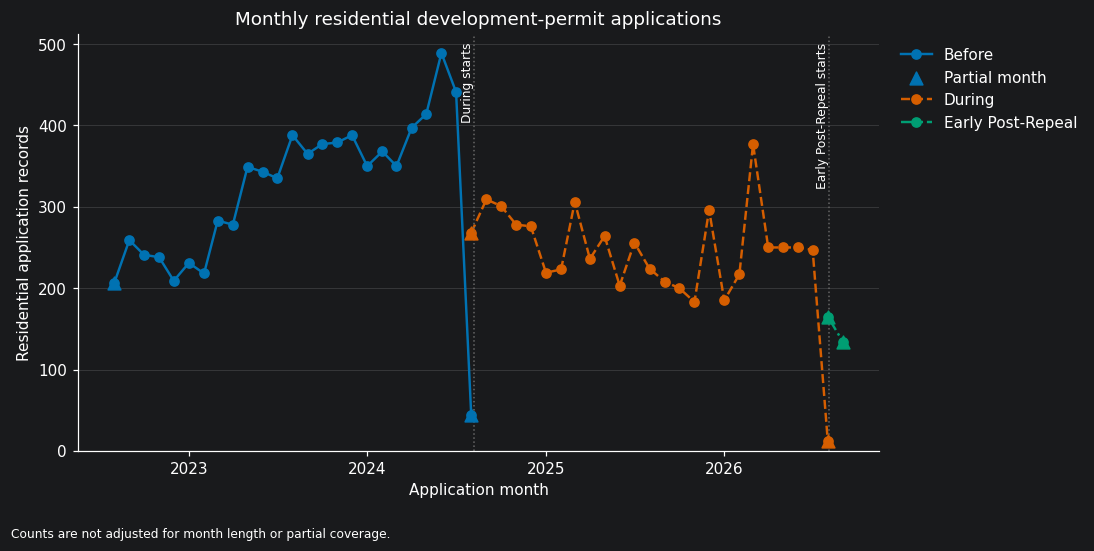

In [14]:
INCLUDE_PARTIAL_SEASONS = False
SEASON_YEAR_METRIC = "PermitCount"
chart_factory = ChartFactory()
figures = {}
covered_start = covered_periods[0].start
covered_end = observation_end
policy_boundaries = {
    f"{period.name} starts": period.start
    for period in config.periods[1:]
    if covered_start <= period.start <= covered_end + timedelta(days=1)
}
figures["monthly_volume"] = chart_factory.monthly_volume(
    analysis_tables["monthly_volume"], policy_boundaries=policy_boundaries,
)
image_buffer = BytesIO()
figures["monthly_volume"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

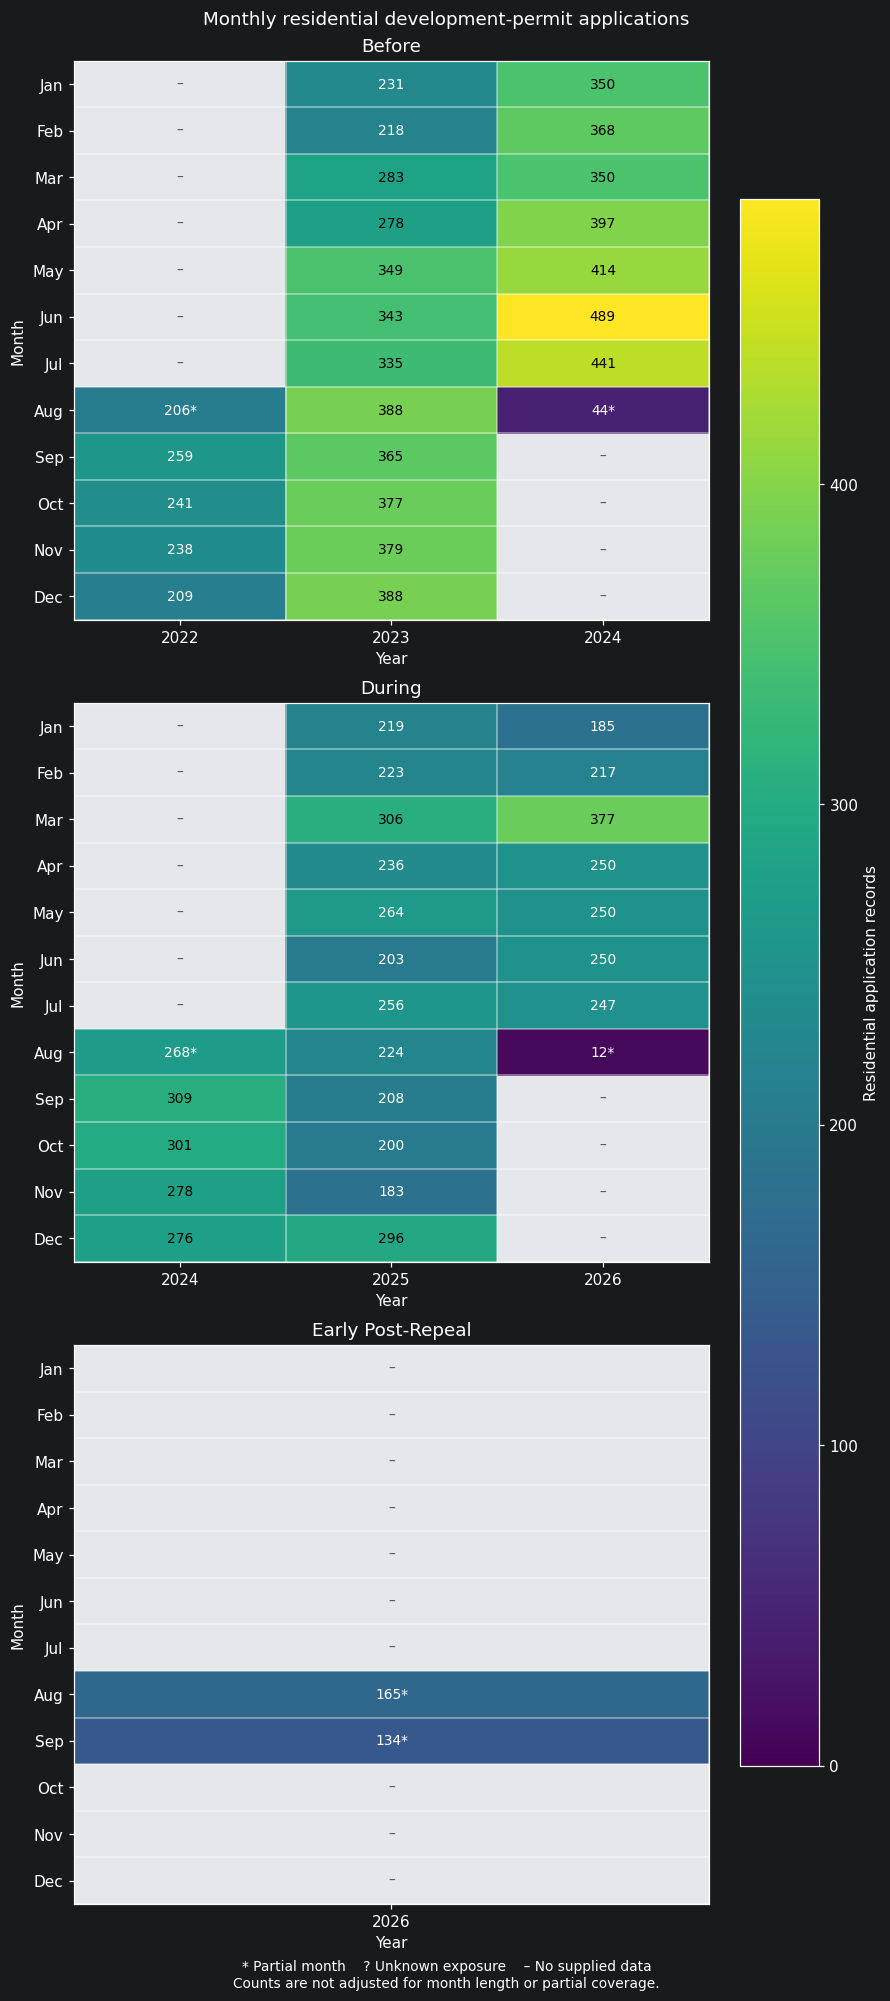

In [15]:
figures["month_year"] = chart_factory.monthly_heatmap(analysis_tables["monthly_volume"])
image_buffer = BytesIO()
figures["month_year"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

## Seasonal charts

Complete seasons are shown by default. Set `INCLUDE_PARTIAL_SEASONS=True` above to include boundary fragments. A missing post-repeal seasonal cell does not imply zero activity. Winter is assigned to its ending year. Policy-period rates pool counts and exposure as sum(count)/sum(days) × 30.

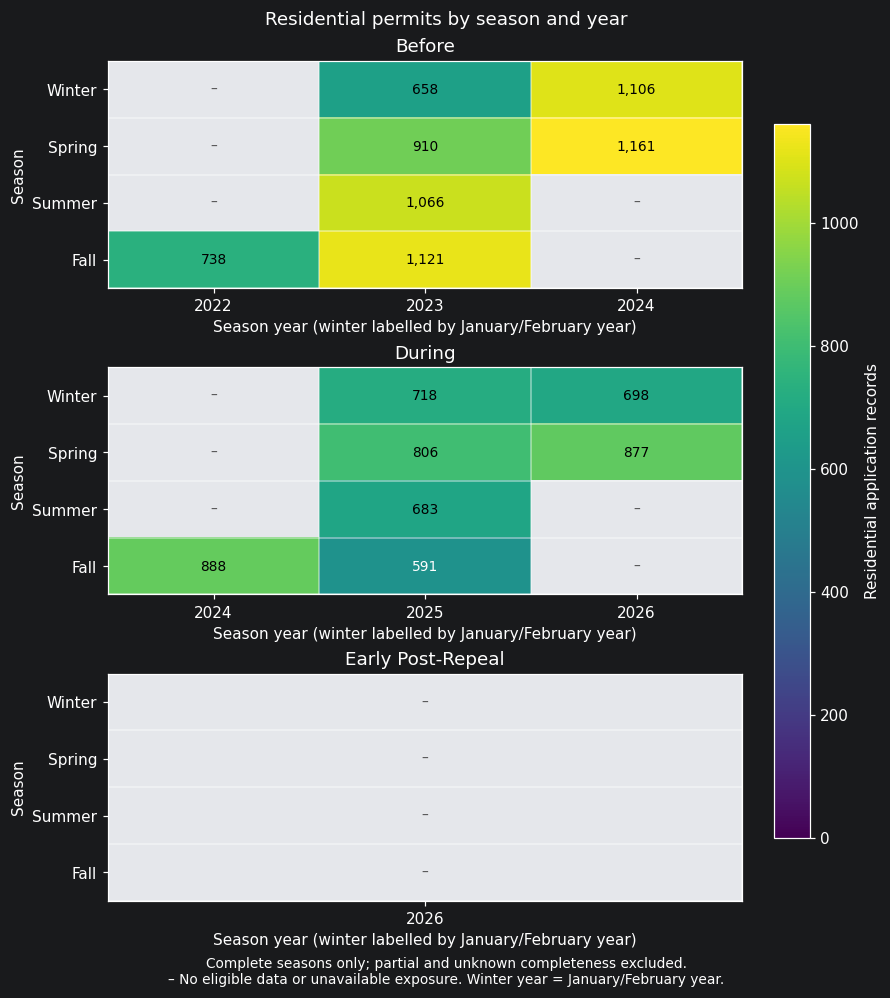

In [16]:
figures["season_year"] = chart_factory.seasonal_year_heatmap(
    analysis_tables["seasonal_summary"], metric=SEASON_YEAR_METRIC,
    include_partial=INCLUDE_PARTIAL_SEASONS,
)
image_buffer = BytesIO()
figures["season_year"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

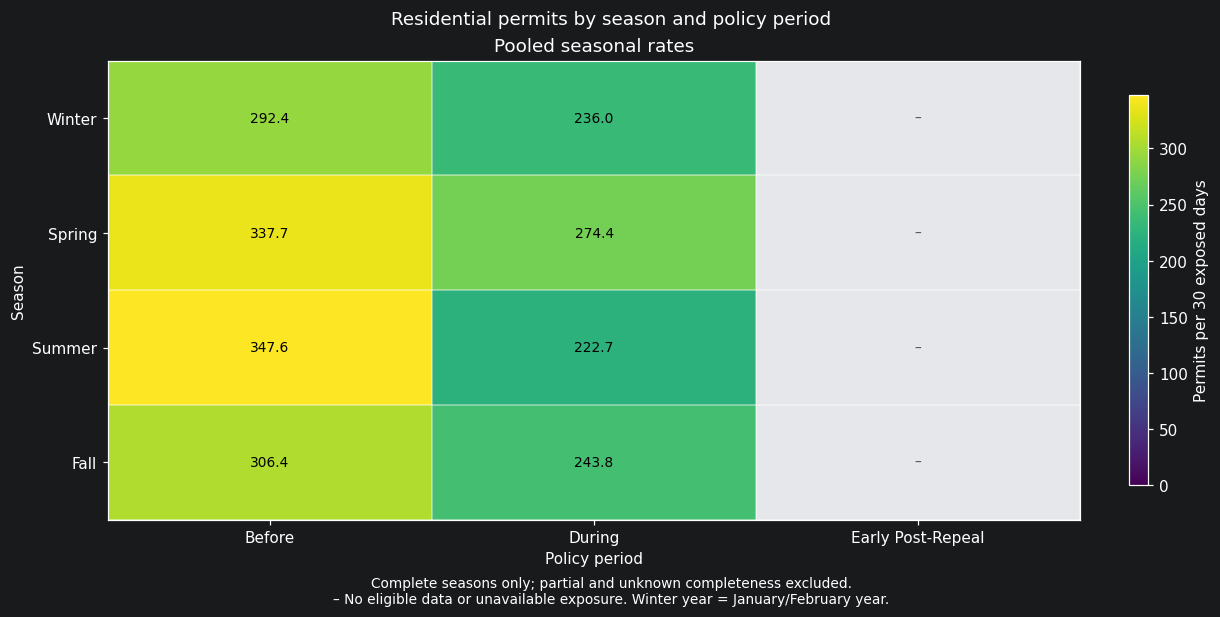

In [17]:
# A wider canvas accommodates all policy-period labels.
figures["season_period"] = ChartFactory({"figure.figsize": (11, 5.5)}).seasonal_period_heatmap(
    analysis_tables["seasonal_summary"], include_partial=INCLUDE_PARTIAL_SEASONS,
)
image_buffer = BytesIO()
figures["season_period"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

## Optional exploratory exports

Set `EXPORT_EXPLORATORY_OUTPUTS=True` to save the featured permit records, analysis tables, validation reports, and four PNG charts. The default writes no export files.

Each enabled run creates a separate directory under `reports/notebook_complete_period/`, with `tables/` and `figures/` subdirectories. Tables use the configured processed-output formats and labels; overwrite is disabled. The cell displays the paths of exported files.

These are exploratory outputs. Validation warnings remain for review, and exporting does not certify classification accuracy, source completeness, or Power BI agreement.

In [18]:
EXPORT_EXPLORATORY_OUTPUTS = False
notebook_output_paths = {}
if EXPORT_EXPLORATORY_OUTPUTS:
    from uuid import uuid4
    from dp_activity.export.powerbi_exporter import PowerBIExporter
    from dp_activity.repositories.output_repository import OutputRepository

    # Isolate each run so table and chart exports preserve previous artifacts.
    notebook_output_dir = ROOT / "reports" / "notebook_complete_period" / uuid4().hex
    notebook_exporter = PowerBIExporter(
        output_repository=OutputRepository(notebook_output_dir / "tables", overwrite_outputs=False),
        output_formats=config.processed_output_formats,
        base_name="complete_period_exploration",
        output_names=config.raw.get("outputs", {}),
    )
    notebook_output_paths = notebook_exporter.export(
        featured, analysis_tables,
        {"schema_validator": schema_issues, "data_quality_validator": quality_results,
         "classification_validator": classification_validation},
    )
    for name, figure in figures.items():
        notebook_output_paths[f"chart_{name}"] = chart_factory.save(
            figure, notebook_output_dir / "figures" / f"{name}.png",
        )
    display(pd.DataFrame([
        {"output": name, "path": str(path.relative_to(ROOT))}
        for name, path in notebook_output_paths.items()
    ]))
else:
    print("Exploratory exports disabled; no table or chart files written.")
assert_frame_equal(featured, analysis_input)
assert_frame_equal(raw, raw_before)

Exploratory exports disabled; no table or chart files written.


## Interpretation and remaining review

Read the refreshed outputs above for findings. Compare Before and During using counts, exposure, type shares, community baseline flags, and eligible processing distributions. The early post-repeal window is shorter and has less follow-up; it is not an equivalent third comparison period.

Validation reports remain visible and do not automatically prevent analysis. Investigate duplicates, missing fields, unmatched classifications, overlapping rules, and pending applications before reporting conclusions. Counts are not dwelling units, and associations do not demonstrate policy effects. Independent classification review, study-specific sensitivity analyses, minimum follow-up choices, and Power BI reconciliation remain outstanding.

Optional table and chart exports are disabled by default; enable them in the section above when needed. To preserve a deliberately refreshed snapshot for later offline runs, copy the printed filename into `SNAPSHOT_FILENAME` and return `REFRESH_DOWNLOAD` to `False`.